<a href="https://colab.research.google.com/gist/nestorsanchez3996-spec/40f02c72e485ed86fa3ad88d79cb685d/proyecto_nusc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>










#UNIVERSIDAD DE GUADALAJARA
Centro Universitario de Ciencias Económico Administrativas (CUCEA)
Estadística I
## Proyecto final de Estadística I
Análisis Estadístico Integral de Subsidios a Combustibles Fósiles\n(Estonia 2010-2024)

**Alumno:** Nestor Uriel Sánchez Cuevas

**Profesor**: Rigoberto Silva Robles

**Fecha**: Mayo 2026


**Introducción**

En este proyecto se realizó un análisis estadístico de los datos financieros correspondientes a los subsidios a los combustibles fósiles en Estonia durante el periodo 2010-2024. Para el desarrollo del trabajo se utilizó Python como herramienta principal para procesar los datos, realizar cálculos estadísticos y generar gráficas que facilitan la interpretación de la información.

El objetivo fue aplicar los temas vistos en la materia de Estadística I, incluyendo medidas de tendencia central, medidas de dispersión, probabilidad, distribuciones de probabilidad (Binomial y Poisson) e índices estadísticos aplicados a la economía energética. Los datos fueron previamente limpiados y organizados para garantizar resultados correctos, y posteriormente se analizaron mediante distintos métodos matemáticos y gráficos.

**Carga y limpieza de datos**

En esta sección se cargó el archivo de datos (en formato Excel/CSV) con los registros históricos de los subsidios otorgados por el gobierno de Estonia.

Primero se identificó la estructura de la tabla real para verificar la disposición de las filas y columnas. Después se eliminaron filas vacías, columnas innecesarias para el alcance del estudio y se convirtieron los datos de apoyo financiero a valores numéricos homogéneos (convertidos formalmente a Millones de EUR). Este proceso es importante porque permite trabajar con una base limpia y organizada para realizar correctamente los cálculos estadísticos sin distorsiones por valores nulos o formatos de texto incorrectos.

**Interpretación:**

Después de limpiar los datos, la tabla quedó organizada por columnas temporales (años fiscales del 2010 al 2024) y por el tipo de sector energético beneficiado (Gas Natural, Exenciones Fiscales generales, etc.). Esto permite utilizar la totalidad de los 70 registros instrumentales históricos como la base principal para calcular de manera exacta las medidas estadísticas del proyecto y
alimentar los modelos probabilísticos teóricos.






In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
# 1. Instalar el compilador de LaTeX en el servidor de Google Colab
!apt-get update
!apt-get install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super

# 2. Instalar la librería de Python para interactuar con LaTeX (si planeas usarla)
!pip install pylatex

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,945 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 5,369 kB in 3s (2,046 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it

In [8]:
import os
import zipfile
import xml.etree.ElementTree as ET
from math import factorial, comb, perm, sqrt, exp, log, pi
import numpy as np
from scipy import stats
from google.colab import files # Librería específica para Colab

# ─────────────────────────────────────────────────────────────────────────────
# CARGA DE ARCHIVO EN GOOGLE COLAB
# ─────────────────────────────────────────────────────────────────────────────

NOMBRE_ARCHIVO_EXPECTED = "OECD_TAD_ADM_DSD_FFS_DF_FFS_EST_3_0_filtered_2026-05-18_12-05-03.xlsx"

# Verifica si el archivo ya está en el entorno de Colab; si no, pide subirlo
if not os.path.exists(NOMBRE_ARCHIVO_EXPECTED):
    print(f"Por favor, sube el archivo: {NOMBRE_ARCHIVO_EXPECTED}")
    uploaded = files.upload()

    # If the file was just uploaded, use the actual uploaded filename
    if uploaded:
        NOMBRE_ARCHIVO = list(uploaded.keys())[0]
    else:
        NOMBRE_ARCHIVO = NOMBRE_ARCHIVO_EXPECTED # Fallback if no file was uploaded
else:
    NOMBRE_ARCHIVO = NOMBRE_ARCHIVO_EXPECTED

# En Colab, los archivos subidos se guardan directamente en la ruta actual (/content/)
RUTA_ARCHIVO = NOMBRE_ARCHIVO

# ─────────────────────────────────────────────────────────────────────────────
# LECTURA DEL EXCEL SIN DEPENDENCIAS EXTERNAS (zipfile + xml)
# ─────────────────────────────────────────────────────────────────────────────

NS = "{http://schemas.openxmlformats.org/spreadsheetml/2006/main}"

def col_letra_a_indice(letra):
    """Convierte letra(s) de columna Excel a indice 0-based. Ej: 'A'->0, 'Z'->25, 'AA'->26."""
    idx = 0
    for ch in letra.upper():
        idx = idx * 26 + (ord(ch) - 64)
    return idx - 1

def leer_xlsx(ruta):
    """
    Lee el archivo .xlsx usando solo zipfile y xml.etree (stdlib).
    Devuelve lista de dicts {col_index: valor} por cada fila.
    Los valores '..' son tratados como None.
    """
    with zipfile.ZipFile(ruta, "r") as z:
        # Cadenas compartidas
        ss_xml = ET.parse(z.open("xl/sharedStrings.xml"))
        shared_strings = [
            "".join(t.text or "" for t in si.iter(f"{NS}t"))
            for si in ss_xml.findall(f"{NS}si")
        ]

        # Hoja 1
        ws_xml = ET.parse(z.open("xl/worksheets/sheet1.xml"))
        filas = []
        for row_el in ws_xml.findall(f".//{NS}row"):
            fila = {}
            for cell in row_el.findall(f"{NS}c"):
                ref = cell.get("r", "")
                col_letra = "".join(ch for ch in ref if ch.isalpha())
                col_idx   = col_letra_a_indice(col_letra)
                tipo      = cell.get("t", "")
                val_el    = cell.find(f"{NS}v")

                if val_el is None:
                    fila[col_idx] = None
                elif tipo == "s":
                    fila[col_idx] = shared_strings[int(val_el.text)]
                else:
                    texto = val_el.text
                    if texto in ("..", ""):
                        fila[col_idx] = None
                    else:
                        try:
                            fila[col_idx] = float(texto)
                        except (ValueError, TypeError):
                            fila[col_idx] = texto
            filas.append(fila)
    return filas

def cargar_datos():
    """
    Extrae las filas con datos numericos del xlsx.
    Estructura de columnas:
        col 1  -> Instrumento
        col 4  -> Tipo de combustible
        col 6  -> 2010 ... col 20 -> 2024
    """
    filas_raw = leer_xlsx(RUTA_ARCHIVO)
    anos = list(range(2010, 2025))
    ignorar = {"Time", "Institutional", "mechanism", "Terms", "Fossil Fuel"}

    nombres_cortos = {
        "Excise Duty Exemption for Fuels Used in Domestic Commercial Fishing": "Exencion Pesca Domestica",
        "Excise Duty Exemption for Oil Shale Used in District Heating": "Exencion Oil Shale Calefaccion",
        "Excise Duty Exemption for Heating Fuels Used by Households": "Exencion Combustible Hogares",
        "Excise Duty Reduction for Diesel Fuel and Light Heating Oil Used for Special Purposes": "Reduccion Diesel Usos Especiales",
        "Excise-Duty Exemption for Fuels Used in Mineralogical Processes": "Exencion Proc. Mineralogicos",
        "Excise-Duty Exemption for Natural Gas Used in Network Operation": "Exencion Gas Red",
        "Feed-In Premium for Fossil Fuels Used in efficient CHP Plants": "Prima CHP Carbon",
        "Excise-Duty Exemption for Fossil Fuels Used for Electricity Production": "Exencion Elect. (Turba/Gas)",
        "Reduced excise duty rate for gas-intensive production": "Tasa Reducida Gas Intensivo",
        "Reduced excise duty rate for electricity-intensive production": "Tasa Reducida Elect. Intensiva",
        "Lower excise rate on diesel in Agriculture And Fishing": "Tasa Baja Diesel Agro/Pesca",
        "Excise Duty Exemption for Electricity Used in Chemical, Electrolytic, and Metallurgical Processes": "Exencion Elect. Industrial",
        "Direct Project Grants to Producers of Shale-Derived Oil": "Subsidio Productores Oil Shale",
        "Direct Project Grants to Oil-Shale-Based Electricity and Heat Production": "Subsidio Elect./Calor Oil Shale",
        "Electricity network fee compensation for all consumers": "Compensacion Red Elect. (Todos)",
        "Electricity network fee compensation for low-income households": "Compensacion Red Elect. (Bajos)",
        "Partial electrity price compensation for households": "Compensacion Precio Elect. Hogares",
        "Compensation for discrict heating costs": "Compensacion Calefaccion Dist.",
        "Compensation of 100% of gas network fee for all consumers": "Compensacion 100pct Red Gas",
        "Compensation in the price of district heating for household consumers": "Compensacion Calef. Distrital Hogares",
        "Support to natural gas network operators and cogeneration of natural gas": "Apoyo Operadores Gas/Cogeneracion",
        "Gas price compensation": "Compensacion Precio Gas",
        "Price ceiling for household gas consumers": "Techo Precio Gas Hogares",
        "Price ceiling for household electricity consumers": "Techo Precio Elect. Hogares",
        "Compensation for Farmers and Fishers for an Increased Excise Duty on Diesel": "Compensacion Diesel Agricultores",
    }

    datos = []
    for fila in filas_raw:
        instr = str(fila.get(1, "") or "")
        if not instr or any(kw in instr for kw in ignorar):
            continue
        yr_vals = [fila.get(6 + i) for i in range(15)]
        nums = [v for v in yr_vals if isinstance(v, float)]
        if not nums:
            continue
        nombre_corto = nombres_cortos.get(instr, instr[:45])
        combustible  = str(fila.get(4, "") or "")
        # Quitar prefijos de indentacion del xlsx
        combustible  = combustible.replace("\u2007", " ").strip().lstrip(".- ")
        fila_limpia  = {"Instrumento": nombre_corto, "Combustible": combustible}
        for i, anio in enumerate(anos):
            val = fila.get(6 + i)
            fila_limpia[str(anio)] = float(val) if isinstance(val, float) else None
        datos.append(fila_limpia)
    return datos, anos


# ─────────────────────────────────────────────────────────────────────────────
# CARGA
# ─────────────────────────────────────────────────────────────────────────────

datos, anos = cargar_datos()
yr_cols = [str(a) for a in anos]
N_MED   = len(datos)

def buscar(nombre):
    """Devuelve el array numpy de una medida por nombre corto."""
    for r in datos:
        if r["Instrumento"] == nombre:
            return np.array([r[y] if r[y] is not None else np.nan for y in yr_cols])
    return np.full(len(anos), np.nan)

def totales_anuales_MEur():
    """Suma de todos los subsidios por ano en millones de EUR."""
    resultado = np.zeros(len(anos))
    for r in datos:
        for i, y in enumerate(yr_cols):
            if r[y] is not None:
                resultado[i] += r[y]
    return resultado / 1e6

totales = totales_anuales_MEur()

SEP = "=" * 70


# ===========================================================================
# TEMA 1 - INTRODUCCION
# ===========================================================================

print(SEP)
print("TEMA 1 - INTRODUCCION AL CONJUNTO DE DATOS")
print(SEP)
print("Pais   : Estonia")
print("Fuente : OCDE - Fossil Fuel Support")
print("Unidad : Euros (EUR)")
print("Periodo: 2010-2024  ({} anos)".format(len(anos)))
print("Medidas de subsidio identificadas: {}".format(N_MED))

print("\nListado de medidas:")
for i, r in enumerate(datos, 1):
    print("  {:2d}. {}".format(i, r["Instrumento"]))

print("\nTotal de subsidios por ano (Millones EUR):")
MAX_BAR = 40
max_val  = totales.max()
for a, t in zip(anos, totales):
    barra = "#" * int(t / max_val * MAX_BAR)
    print("  {}: {:8.2f} M EUR  {}".format(a, t, barra))

print("\nResumen rapido:")
print("  Minimo : {:.2f} M EUR  (ano {})".format(totales.min(), anos[np.argmin(totales)]))
print("  Maximo : {:.2f} M EUR  (ano {})".format(totales.max(), anos[np.argmax(totales)]))
print("  Media  : {:.2f} M EUR".format(totales.mean()))


# ===========================================================================
# TEMA 2 - MEDIDAS DE TENDENCIA CENTRAL
# ===========================================================================

print("\n" + SEP)
print("TEMA 2 - MEDIDAS DE TENDENCIA CENTRAL")
print(SEP)

# ── 2.1 a 2.3  Datos Agrupados ─────────────────────────────────────────────
print("\n-- 2.1 a 2.3  DATOS AGRUPADOS (Total anual en M EUR, 5 intervalos) --")

def estadisticas_agrupadas(serie, n_int=5, etiqueta="M EUR"):
    """Calcula Moda (Bohmer), Mediana y Media para datos agrupados."""
    serie = serie[~np.isnan(serie)]
    mn, mx  = serie.min(), serie.max()
    amplitud = (mx - mn) / n_int
    limite   = [mn + k * amplitud for k in range(n_int + 1)]
    freqs, marcas = [], []

    for k in range(n_int):
        li, ls = limite[k], limite[k + 1]
        fi = int(np.sum((serie >= li) & (serie < (ls if k < n_int - 1 else ls + 1e-9))))
        freqs.append(fi)
        marcas.append((li + ls) / 2)

    fi = np.array(freqs, dtype=float)
    mc = np.array(marcas)
    N  = fi.sum()

    print("\n  {:<22} {:<14} {:<16} {}".format("Intervalo", "Marca (xi)", "Frec. (fi)", "fi * xi"))
    print("  " + "-" * 62)
    for k in range(n_int):
        iv = "[{:.2f}, {:.2f})".format(limite[k], limite[k+1])
        print("  {:<22} {:<14.2f} {:<16} {:.2f}".format(iv, mc[k], int(fi[k]), fi[k]*mc[k]))
    print("  " + "-" * 62)
    print("  {:<22} {:<14} {:<16} {:.2f}".format("TOTAL", "", int(N), np.sum(fi*mc)))

    # Moda - formula de Bohmer
    idx_mod = int(np.argmax(fi))
    d1 = fi[idx_mod] - (fi[idx_mod - 1] if idx_mod > 0 else 0)
    d2 = fi[idx_mod] - (fi[idx_mod + 1] if idx_mod < n_int - 1 else 0)
    moda_ag = (limite[idx_mod] + (d1 / (d1 + d2) if (d1 + d2) != 0 else 0.5) * amplitud)

    # Mediana
    F_acum, mediana_ag = 0, None
    for k in range(n_int):
        if F_acum + fi[k] >= N / 2:
            mediana_ag = limite[k] + ((N / 2 - F_acum) / fi[k]) * amplitud
            break
        F_acum += fi[k]

    # Media
    media_ag = np.sum(fi * mc) / N

    print("\n  2.1 Moda    agrupada (Bohmer) : {:.4f} {}".format(moda_ag, etiqueta))
    print("  2.2 Mediana agrupada          : {:.4f} {}".format(mediana_ag, etiqueta))
    print("  2.3 Media   agrupada          : {:.4f} {}".format(media_ag, etiqueta))
    return moda_ag, mediana_ag, media_ag

moda_ag, med_ag, mean_ag = estadisticas_agrupadas(totales)

# ── 2.4 a 2.6  Datos No Agrupados ─────────────────────────────────────────
print("\n-- 2.4 a 2.6  DATOS NO AGRUPADOS (Total anual en M EUR) --")

totales_redon = np.round(totales, 1)
print("\n  Datos:", list(totales_redon))

# 2.4 Moda
valores_unicos, conteos = np.unique(totales_redon, return_counts=True)
idx_moda   = np.argmax(conteos)
moda_val   = valores_unicos[idx_moda]
moda_count = conteos[idx_moda]
print("\n  2.4 Moda: {} M EUR  (aparece {} vez/veces)".format(moda_val, moda_count))
if moda_count == 1:
    print("       Nota: todos los valores son distintos (moda amodal en datos continuos)")

# 2.5 Mediana
n          = len(totales)
ord_vals   = np.sort(totales)
if n % 2 == 0:
    mediana = (ord_vals[n // 2 - 1] + ord_vals[n // 2]) / 2
    print("  2.5 Mediana: ({:.2f} + {:.2f}) / 2 = {:.4f} M EUR".format(
          ord_vals[n//2-1], ord_vals[n//2], mediana))
else:
    mediana = ord_vals[n // 2]
    print("  2.5 Mediana: {:.4f} M EUR  (posicion {} del ordenamiento)".format(
          mediana, n // 2 + 1))

# 2.6 Media
media = totales.mean()
print("  2.6 Media: {:.4f} M EUR  (suma={:.2f} / n={})".format(media, totales.sum(), n))


# ===========================================================================
# TEMA 3 - MEDIDAS DE DISPERSION
# ===========================================================================

print("\n" + SEP)
print("TEMA 3 - MEDIDAS DE DISPERSION")
print(SEP)
print("  Serie: Subsidio Total Anual Estonia (M EUR) -- {} datos\n".format(n))

# 3.1 Rango
rango = totales.max() - totales.min()
print("  3.1 Rango = Max - Min = {:.2f} - {:.2f} = {:.4f} M EUR".format(
      totales.max(), totales.min(), rango))

# 3.2 Rango Intercuartilico
Q1  = np.percentile(totales, 25)
Q2  = np.percentile(totales, 50)
Q3  = np.percentile(totales, 75)
RIC = Q3 - Q1
print("  3.2 Rango Intercuartilico (RIC) = Q3 - Q1 = {:.4f} - {:.4f} = {:.4f} M EUR".format(Q3, Q1, RIC))
print("       Q1={:.4f}  Q2={:.4f}  Q3={:.4f}  M EUR".format(Q1, Q2, Q3))

# 3.3 Varianza
var_pob = np.var(totales)
var_mue = np.var(totales, ddof=1)
print("  3.3 Varianza poblacional (sigma^2)  = {:.4f}".format(var_pob))
print("      Varianza muestral    (s^2)      = {:.4f}".format(var_mue))

# 3.4 Desviacion Estandar
std_pob = np.std(totales)
std_mue = np.std(totales, ddof=1)
CV      = std_mue / media * 100
print("  3.4 Desv. Estandar poblacional (sigma) = {:.4f} M EUR".format(std_pob))
print("      Desv. Estandar muestral    (s)     = {:.4f} M EUR".format(std_mue))
print("      Coeficiente de Variacion (CV)       = s/x_barra = {:.2f}%".format(CV))

# 3.5 Desviacion Media
desv_media = np.mean(np.abs(totales - media))
print("  3.5 Desviacion Media (DM) = suma|xi-x_barra|/n = {:.4f} M EUR".format(desv_media))

print("\n  Tabla resumen de dispersion:")
print("  {:<42} {:>14}".format("Medida", "Valor"))
print("  " + "-" * 57)
for etiq, val, ud in [
    ("Media (x_barra)",          media,     "M EUR"),
    ("Rango",                    rango,     "M EUR"),
    ("Rango Intercuartilico (RIC)", RIC,    "M EUR"),
    ("Desviacion Media (DM)",    desv_media, "M EUR"),
    ("Varianza muestral (s^2)", var_mue,    ""),
    ("Desv. Estandar muestral (s)", std_mue, "M EUR"),
]:
    print("  {:<42} {:>14.4f}  {}".format(etiq, val, ud))


# ===========================================================================
# TEMA 4 - INTRODUCCION A LA PROBABILIDAD
# ===========================================================================

print("\n" + SEP)
print("TEMA 4 - INTRODUCCION A LA PROBABILIDAD")
print(SEP)

# Clasificacion de combustibles
def contiene(col, *kws):
    return sum(1 for r in datos if any(k in r["Combustible"] for k in kws))

n_diesel  = contiene("Combustible", "diesel oil", "Gas/diesel")
n_gas     = contiene("Combustible", "Natural Gas")
n_elect   = contiene("Combustible", "electricity")
n_carbon  = contiene("Combustible", "Coal", "Peat", "Oil Shale", "Bituminous", "Shale")
n_otros   = N_MED - n_diesel - n_gas - n_elect - n_carbon

grupos = [
    ("Gas/diesel oil",         n_diesel),
    ("Gas Natural",            n_gas),
    ("Electricidad uso final", n_elect),
    ("Carbon/Turba/Oil Shale", n_carbon),
    ("Otros",                  n_otros),
]

print("\n  Espacio muestral: {} medidas de subsidio en Estonia".format(N_MED))
print("\n  Frecuencias por tipo de combustible:")
print("  {:<28} {:>4}  {:>8}  {:>8}".format("Tipo", "fi", "P(A)", "%"))
print("  " + "-" * 55)
for nombre, fi in grupos:
    p = fi / N_MED
    print("  {:<28} {:>4}  {:>8.4f}  {:>7.1f}%".format(nombre, fi, p, p * 100))

p_diesel = n_diesel / N_MED
p_gas    = n_gas    / N_MED
p_elect  = n_elect  / N_MED
p_carbon = n_carbon / N_MED

# 4.1 Diagrama de Venn (en texto ASCII)
print("\n  4.1 DIAGRAMA DE VENN -- Subsidios por tipo de energia")
print("  +---------------------------------------------------------+")
print("  |  UNIVERSO: {} medidas de subsidio en Estonia            |".format(N_MED))
print("  |                                                         |")
print("  |   +--------------------+   +------------------------+   |")
print("  |   | FOSILES LIQUIDOS   |   |  FOSILES GASEOSOS      |   |")
print("  |   |  Diesel/Gas oil: {}  |   |  Gas Natural: {}        |   |".format(n_diesel, n_gas))
print("  |   +--------------------+   +------------------------+   |")
print("  |                                                         |")
print("  |   +--------------------+   +------------------------+   |")
print("  |   | CARBON/TURBA/SHALE |   |  ELECTRICIDAD          |   |")
print("  |   |  Coal/Oil Shale: {}  |   |  End-use elect: {}      |   |".format(n_carbon, n_elect))
print("  |   +--------------------+   +------------------------+   |")
print("  +---------------------------------------------------------+")

# 4.2 Conteo (Principio Multiplicativo)
print("\n  4.2 CONTEO -- Principio Multiplicativo")
print("  Tipos de combustible: {}".format(len(grupos)))
tipos_soporte    = 2   # exencion fiscal / transferencia presupuestaria
tipos_etapa      = 4   # extraccion, transporte, generacion, uso final
comb_posibles    = len(grupos) * tipos_soporte * tipos_etapa
print("  Tipos combustible({}) x Tipos soporte({}) x Etapas({}) = {}".format(
      len(grupos), tipos_soporte, tipos_etapa, comb_posibles))
print("  Total de combinaciones posibles = {}".format(comb_posibles))

# 4.3 Combinacion
print("\n  4.3 COMBINACION C(n,r)")
r_aud = 5
c_val = comb(N_MED, r_aud)
print("  Auditar {} de {} medidas (sin importar orden):".format(r_aud, N_MED))
print("  C({},{}) = {}! / ({}! x {}!) = {:,}".format(
      N_MED, r_aud, N_MED, r_aud, N_MED - r_aud, c_val))

# 4.4 Permutacion
print("\n  4.4 PERMUTACION P(n,r)")
r_per = 4
p_val = perm(N_MED, r_per)
print("  Revisar {} medidas en orden especifico:".format(r_per))
print("  P({},{}) = {}! / {}! = {:,}".format(N_MED, r_per, N_MED, N_MED - r_per, p_val))

# 4.5 Probabilidad Condicional
print("\n  4.5 PROBABILIDAD CONDICIONAL  P(A|B)")
print("  A = medida involucra Gas Natural")
print("  B = medida es una exencion fiscal")

kws_exencion = ["Exencion", "Reduccion", "Tasa Reducida", "Tasa Baja", "Techo"]
n_B  = sum(1 for r in datos if any(k in r["Instrumento"] for k in kws_exencion))
n_AB = sum(1 for r in datos if any(k in r["Instrumento"] for k in kws_exencion)
                             and "Natural Gas" in r["Combustible"])
P_B       = n_B  / N_MED
P_AB      = n_AB / N_MED
P_A_dado_B = P_AB / P_B if P_B > 0 else 0

print("  P(B) = {}/{} = {:.4f}".format(n_B, N_MED, P_B))
print("  P(A interseccion B) = {}/{} = {:.4f}".format(n_AB, N_MED, P_AB))
print("  P(A|B) = P(A interseccion B) / P(B) = {:.4f} / {:.4f} = {:.4f}".format(
      P_AB, P_B, P_A_dado_B))

# 4.6 Teorema de Bayes
print("\n  4.6 TEOREMA DE BAYES  P(A|B) = P(B|A) * P(A) / P(B)")
print("  Pregunta: P(exencion | Gas Natural)?")
n_gas_y_exen = n_AB
P_B_dado_A   = n_gas_y_exen / n_gas if n_gas > 0 else 0
P_A_bayes    = (P_B_dado_A * p_gas) / P_B if P_B > 0 else 0
print("  P(Gas Natural)         = P(A) = {:.4f}".format(p_gas))
print("  P(exencion|Gas Nat.)   = P(B|A) = {}/{} = {:.4f}".format(
      n_gas_y_exen, n_gas, P_B_dado_A))
print("  P(exencion)            = P(B) = {:.4f}".format(P_B))
print("  Bayes: P(A|B) = {:.4f} x {:.4f} / {:.4f} = {:.4f}".format(
      P_B_dado_A, p_gas, P_B, P_A_bayes))
print("  Verificacion: P(A|B) directo = {:.4f}  [coincide: {}]".format(
      P_A_dado_B, abs(P_A_dado_B - P_A_bayes) < 1e-9))


# ===========================================================================
# TEMA 5 - DISTRIBUCIONES CON VARIABLE ALEATORIA DISCRETA (VAD)
# ===========================================================================

print("\n" + SEP)
print("TEMA 5 - DISTRIBUCIONES DE PROBABILIDAD CON VAD")
print(SEP)

# 5.1 Distribucion Binomial
print("\n  5.1 DISTRIBUCION BINOMIAL  B(n, p)")
print("  Escenario: Cada una de las {} medidas tiene p=0.40 de superar".format(N_MED))
print("  su nivel promedio historico en un ano dado.")
n_bin = N_MED
p_bin = 0.40
mu_bin  = n_bin * p_bin
sig_bin = sqrt(n_bin * p_bin * (1 - p_bin))
print("  n={}, p={}".format(n_bin, p_bin))
print("  Media   mu = n*p = {:.2f}".format(mu_bin))
print("  Desv.   sigma = sqrt(n*p*q) = {:.4f}".format(sig_bin))

print("\n  {:>4} {:>12} {:>12} {:>12}".format("k", "P(X=k)", "P(X<=k)", "P(X>k)"))
print("  " + "-" * 46)
for k in [6, 7, 8, 9, 10, 11, 12]:
    pmf = stats.binom.pmf(k, n_bin, p_bin)
    cdf = stats.binom.cdf(k, n_bin, p_bin)
    print("  {:>4} {:>12.6f} {:>12.6f} {:>12.6f}".format(k, pmf, cdf, 1 - cdf))

print("\n  P(X >= 10)     = {:.6f}".format(1 - stats.binom.cdf(9, n_bin, p_bin)))
print("  P(8 <= X <= 12) = {:.6f}".format(
      stats.binom.cdf(12, n_bin, p_bin) - stats.binom.cdf(7, n_bin, p_bin)))

# 5.2 Distribucion Poisson
print("\n  5.2 DISTRIBUCION POISSON  P(lambda)")
lam = 2.1
print("  Escenario: Media de nuevas medidas aprobadas/ano = lambda={:.1f}".format(lam))
print("  mu = lambda = {:.1f}   |   sigma = sqrt(lambda) = {:.4f}".format(lam, sqrt(lam)))

print("\n  {:>4} {:>12} {:>12} {:>12}".format("k", "P(X=k)", "P(X<=k)", "P(X>k)"))
print("  " + "-" * 46)
for k in range(7):
    pmf = stats.poisson.pmf(k, lam)
    cdf = stats.poisson.cdf(k, lam)
    print("  {:>4} {:>12.6f} {:>12.6f} {:>12.6f}".format(k, pmf, cdf, 1 - cdf))

print("\n  P(X = 0) = e^(-{}) = {:.6f}".format(lam, stats.poisson.pmf(0, lam)))
print("  P(X = 2) = e^(-{}) * {}^2 / 2! = {:.6f}".format(lam, lam, stats.poisson.pmf(2, lam)))
print("  P(X >= 3) = {:.6f}".format(1 - stats.poisson.cdf(2, lam)))

# 5.3 Distribucion Hipergeometrica
print("\n  5.3 DISTRIBUCION HIPERGEOMETRICA  H(N, K, n)")
N_hip = N_MED
K_hip = n_diesel
n_hip = r_aud
mu_hip  = n_hip * K_hip / N_hip
sig_hip = sqrt(n_hip * K_hip * (N_hip - K_hip) * (N_hip - n_hip) / (N_hip**2 * (N_hip - 1)))
print("  De las {} medidas, {} son de gas/diesel (K).".format(N_hip, K_hip))
print("  Se seleccionan n={} medidas para auditoria.".format(n_hip))
print("  N={}, K={}, n={}".format(N_hip, K_hip, n_hip))
print("  mu = n*K/N = {:.4f}   |   sigma = {:.4f}".format(mu_hip, sig_hip))

print("\n  {:>4} {:>12} {:>12}".format("k", "P(X=k)", "P(X<=k)"))
print("  " + "-" * 32)
for k in range(n_hip + 1):
    pmf = stats.hypergeom.pmf(k, N_hip, K_hip, n_hip)
    cdf = stats.hypergeom.cdf(k, N_hip, K_hip, n_hip)
    print("  {:>4} {:>12.6f} {:>12.6f}".format(k, pmf, cdf))

print("\n  P(X = 0) = {:.6f}".format(stats.hypergeom.pmf(0, N_hip, K_hip, n_hip)))
print("  P(X >= 2) = {:.6f}".format(1 - stats.hypergeom.cdf(1, N_hip, K_hip, n_hip)))


# ===========================================================================
# TEMA 6 - DISTRIBUCIONES CON VARIABLE ALEATORIA CONTINUA (VAC)
# ===========================================================================

print("\n" + SEP)
print("TEMA 6 - DISTRIBUCIONES DE PROBABILIDAD CON VAC")
print(SEP)

# Serie: Reduccion Diesel Usos Especiales (tiene datos en todos los anos)
diesel_arr = buscar("Reduccion Diesel Usos Especiales") / 1e6
diesel_lim = diesel_arr[~np.isnan(diesel_arr)]
mu_d  = float(np.mean(diesel_lim))
sig_d = float(np.std(diesel_lim, ddof=1))

print("\n  Serie usada: 'Reduccion Diesel Usos Especiales' 2010-2024 (M EUR)")
print("  Datos: {}".format([round(v, 2) for v in diesel_lim]))
print("  n={}, mu={:.4f} M EUR, sigma={:.4f} M EUR".format(len(diesel_lim), mu_d, sig_d))

stat_sw, p_sw = stats.shapiro(diesel_lim)
print("  Prueba Shapiro-Wilk: W={:.4f}, p-valor={:.4f}".format(stat_sw, p_sw))
print("  -> {}".format("No se rechaza normalidad (alfa=0.05)" if p_sw > 0.05
                        else "Se rechaza normalidad (alfa=0.05) -- datos sesgados"))
print("     (Se aplican formulas normales como ejercicio didactico)")

# 6.1 Distribucion Normal
print("\n  6.1 DISTRIBUCION NORMAL  N(mu={:.2f}, sigma={:.2f})".format(mu_d, sig_d))
puntos_calc = [35.0, 40.0, 45.0, 50.0, 55.0, 60.0]
print("\n  {:>8} {:>12} {:>12}".format("X (M EUR)", "P(X <= x)", "P(X > x)"))
print("  " + "-" * 36)
for xv in puntos_calc:
    c = stats.norm.cdf(xv, mu_d, sig_d)
    print("  {:>8.1f} {:>12.6f} {:>12.6f}".format(xv, c, 1 - c))

print("\n  Regla empirica:")
for k in [1, 2, 3]:
    p = (stats.norm.cdf(mu_d + k*sig_d, mu_d, sig_d)
         - stats.norm.cdf(mu_d - k*sig_d, mu_d, sig_d))
    print("  P(mu-{}sigma < X < mu+{}sigma) = {:.4f}  (~{}%)".format(
          k, k, p, [68, 95, 99][k-1]))

print("\n  Percentiles:")
for pct in [10, 25, 50, 75, 90]:
    print("  P{:2d}: {:.4f} M EUR".format(pct, stats.norm.ppf(pct / 100, mu_d, sig_d)))

# 6.2 Distribucion Normal Estandar
print("\n  6.2 DISTRIBUCION NORMAL ESTANDAR  N(0, 1)")
print("  Estandarizacion: Z = (X - mu) / sigma = (X - {:.2f}) / {:.2f}".format(mu_d, sig_d))

print("\n  {:>10} {:>14} {:>12} {:>12}".format("X (M EUR)", "Z=(X-mu)/sigma", "P(X<=x)", "P(X>x)"))
print("  " + "-" * 54)
for xv in puntos_calc:
    z    = (xv - mu_d) / sig_d
    cdf_ = stats.norm.cdf(z)
    print("  {:>10.2f} {:>14.4f} {:>12.6f} {:>12.6f}".format(xv, z, cdf_, 1 - cdf_))

print("\n  Valores Z criticos:")
for conf, alfa in [(90, 0.10), (95, 0.05), (99, 0.01)]:
    zc = stats.norm.ppf(1 - alfa / 2)
    print("  Confianza {}%: Z(alfa/2) = +/-{:.4f}".format(conf, zc))

print("\n  Ejemplo practico:")
x_ej = 70.0
z_ej = (x_ej - mu_d) / sig_d
print("  Z para {} M EUR = ({} - {:.2f}) / {:.2f} = {:.4f}".format(
      x_ej, x_ej, mu_d, sig_d, z_ej))
print("  P(X > {} M EUR) = P(Z > {:.4f}) = {:.6f}".format(
      x_ej, z_ej, 1 - stats.norm.cdf(z_ej)))


# ===========================================================================
# TEMA 7 - INDICES DE PRECIOS
# ===========================================================================

print("\n" + SEP)
print("TEMA 7 - INDICES DE PRECIOS  (Laspeyres, Paasche, Fisher)")
print(SEP)
print("""
  Interpretacion:
    P (precio) = valor del subsidio por cada 100,000 EUR de referencia
    Q (cantidad) = unidades relativas beneficiadas
  Ano base   : 2010  |  Ano actual: 2020
""")

def fila_vals(nombre, anio):
    arr = buscar(nombre)
    v = arr[anos.index(int(anio))]
    return float(v) if not np.isnan(v) else 0.0

seleccion = [
    ("Reduccion Diesel Usos Especiales", 2010, 2020),
    ("Exencion Pesca Domestica",          2010, 2020),
    ("Prima CHP Carbon",                  2010, 2020),
    ("Exencion Proc. Mineralogicos",      2010, 2020),
]

tabla = []
for nombre, a0, a1 in seleccion:
    v0 = fila_vals(nombre, a0)
    v1 = fila_vals(nombre, a1)
    if v0 == 0 or v1 == 0:
        continue
    P0 = v0 / 100_000
    P1 = v1 / 100_000
    Q0 = 100.0
    Q1 = (v1 / v0) * 100.0
    tabla.append({
        "nombre": nombre[:35],
        "P0": P0, "Q0": Q0, "P1": P1, "Q1": Q1,
        "P0Q0": P0*Q0, "P1Q0": P1*Q0,
        "P0Q1": P0*Q1, "P1Q1": P1*Q1,
    })

encab = "{:<36} {:>8} {:>7} {:>10} {:>10} {:>12} {:>12} {:>12} {:>12}"
print("  " + encab.format("Medida","P0","Q0","P1","Q1","P0*Q0","P1*Q0","P0*Q1","P1*Q1"))
print("  " + "-" * 121)
for r in tabla:
    linea = "{:<36} {:>8.2f} {:>7.1f} {:>10.2f} {:>10.2f} {:>12.2f} {:>12.2f} {:>12.2f} {:>12.2f}"
    print("  " + linea.format(r["nombre"], r["P0"], r["Q0"], r["P1"], r["Q1"],
                               r["P0Q0"], r["P1Q0"], r["P0Q1"], r["P1Q1"]))

SP0Q0 = sum(r["P0Q0"] for r in tabla)
SP1Q0 = sum(r["P1Q0"] for r in tabla)
SP0Q1 = sum(r["P0Q1"] for r in tabla)
SP1Q1 = sum(r["P1Q1"] for r in tabla)
print("  " + "-" * 121)
print("  " + "{:<36} {:>8} {:>7} {:>10} {:>10} {:>12.2f} {:>12.2f} {:>12.2f} {:>12.2f}".format(
      "SUMAS", "", "", "", "", SP0Q0, SP1Q0, SP0Q1, SP1Q1))

# 7.1 Laspeyres
IL = (SP1Q0 / SP0Q0) * 100 if SP0Q0 else 0
print("\n  7.1 Indice de Laspeyres (usa cantidades del ano base Q0):")
print("       IL = suma(P1*Q0) / suma(P0*Q0) * 100")
print("          = {:.2f} / {:.2f} * 100 = {:.4f}".format(SP1Q0, SP0Q0, IL))
print("       Cambio respecto al ano base: {:+.2f}%".format(IL - 100))

# 7.2 Paasche
IP = (SP1Q1 / SP0Q1) * 100 if SP0Q1 else 0
print("\n  7.2 Indice de Paasche (usa cantidades del ano actual Q1):")
print("       IP = suma(P1*Q1) / suma(P0*Q1) * 100")
print("          = {:.2f} / {:.2f} * 100 = {:.4f}".format(SP1Q1, SP0Q1, IP))
print("       Los subsidios en 2020 representan el {:.1f}% de los de 2010".format(IP))

# 7.3 Fisher
IF = sqrt(IL * IP)
print("\n  7.3 Indice de Fisher (media geometrica de Laspeyres y Paasche):")
print("       IF = sqrt(IL * IP) = sqrt({:.4f} * {:.4f}) = {:.4f}".format(IL, IP, IF))
print("       Cambio 'ideal' respecto al ano base: {:+.2f}%".format(IF - 100))

print("\n  Resumen de indices (Base 2010 = 100):")
print("  +------------------------------------------------------+")
print("  |  Indice de Laspeyres  (IL) = {:10.4f}               |".format(IL))
print("  |  Indice de Paasche    (IP) = {:10.4f}               |".format(IP))
print("  |  Indice de Fisher     (IF) = {:10.4f}               |".format(IF))
print("  |                                                      |")
sesgo = "IL > IP --> Laspeyres sobreestima (sesgo al alza)" if IL > IP \
        else "IL < IP --> Laspeyres subestima (sesgo a la baja)"
print("  |  {}  |".format(sesgo[:50]))
print("  +------------------------------------------------------+")


# ===========================================================================
# RESUMEN FINAL
# ===========================================================================

print("\n" + SEP)
print("RESUMEN EJECUTIVO -- SUBSIDIOS FOSILES ESTONIA (OCDE 2010-2024)")
print(SEP)
print("""
  +------------------------------------------------------------------+
  | MEDIDAS DE TENDENCIA CENTRAL  (Total anual, M EUR)               |
  |   Media    (x_barra) = {:>8.2f} M EUR                            |
  |   Mediana  (Me)      = {:>8.2f} M EUR                            |
  |   Moda     (agrup.)  = {:>8.2f} M EUR                            |
  +------------------------------------------------------------------+
  | MEDIDAS DE DISPERSION  (Total anual, M EUR)                      |
  |   Rango              = {:>8.2f} M EUR                            |
  |   RIC                = {:>8.2f} M EUR                            |
  |   Desv. Estandar (s) = {:>8.2f} M EUR                            |
  |   Coef. Variacion    = {:>7.2f}%                                  |
  +------------------------------------------------------------------+
  | PROBABILIDAD                                                      |
  |   P(Gas Natural) = {:.4f}   P(Diesel) = {:.4f}                    |
  |   P(exencion | Gas Natural) = {:.4f}                              |
  +------------------------------------------------------------------+
  | INDICES DE PRECIOS  (2010 --> 2020)                              |
  |   Laspeyres = {:>8.2f}                                           |
  |   Paasche   = {:>8.2f}                                           |
  |   Fisher    = {:>8.2f}                                           |
  +------------------------------------------------------------------+

  Todos los calculos usan datos reales de la OCDE.
""".format(media, mediana, moda_ag,
           rango, RIC, std_mue, CV,
           p_gas, p_diesel, P_B_dado_A,
           IL, IP, IF))

print(SEP)
print("FIN DEL ANALISIS")
print(SEP)

Por favor, sube el archivo: OECD_TAD_ADM_DSD_FFS_DF_FFS_EST_3_0_filtered_2026-05-18_12-05-03.xlsx


Saving OECD.TAD.ADM,DSD_FFS@DF_FFS_EST,3.0,filtered,2026-05-18 12-05-03.xlsx to OECD.TAD.ADM,DSD_FFS@DF_FFS_EST,3.0,filtered,2026-05-18 12-05-03.xlsx
TEMA 1 - INTRODUCCION AL CONJUNTO DE DATOS
Pais   : Estonia
Fuente : OCDE - Fossil Fuel Support
Unidad : Euros (EUR)
Periodo: 2010-2024  (15 anos)
Medidas de subsidio identificadas: 22

Listado de medidas:
   1. Exencion Pesca Domestica
   2. Exencion Oil Shale Calefaccion
   3. Exencion Combustible Hogares
   4. Reduccion Diesel Usos Especiales
   5. Exencion Proc. Mineralogicos
   6. Exencion Gas Red
   7. Tasa Reducida Gas Intensivo
   8. Tasa Reducida Elect. Intensiva
   9. Tasa Baja Diesel Agro/Pesca
  10. Exencion Elect. Industrial
  11. Subsidio Productores Oil Shale
  12. Subsidio Elect./Calor Oil Shale
  13. Compensacion Red Elect. (Todos)
  14. Compensacion Red Elect. (Bajos)
  15. Compensacion Precio Elect. Hogares
  16. Compensacion Calefaccion Dist.
  17. Compensacion 100pct Red Gas
  18. Compensacion Calef. Distrital Hogares

/tmp/ipykernel_4128/2959178690.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=valores_indices, y=nombres_indices, palette='viridis', ax=ax7)


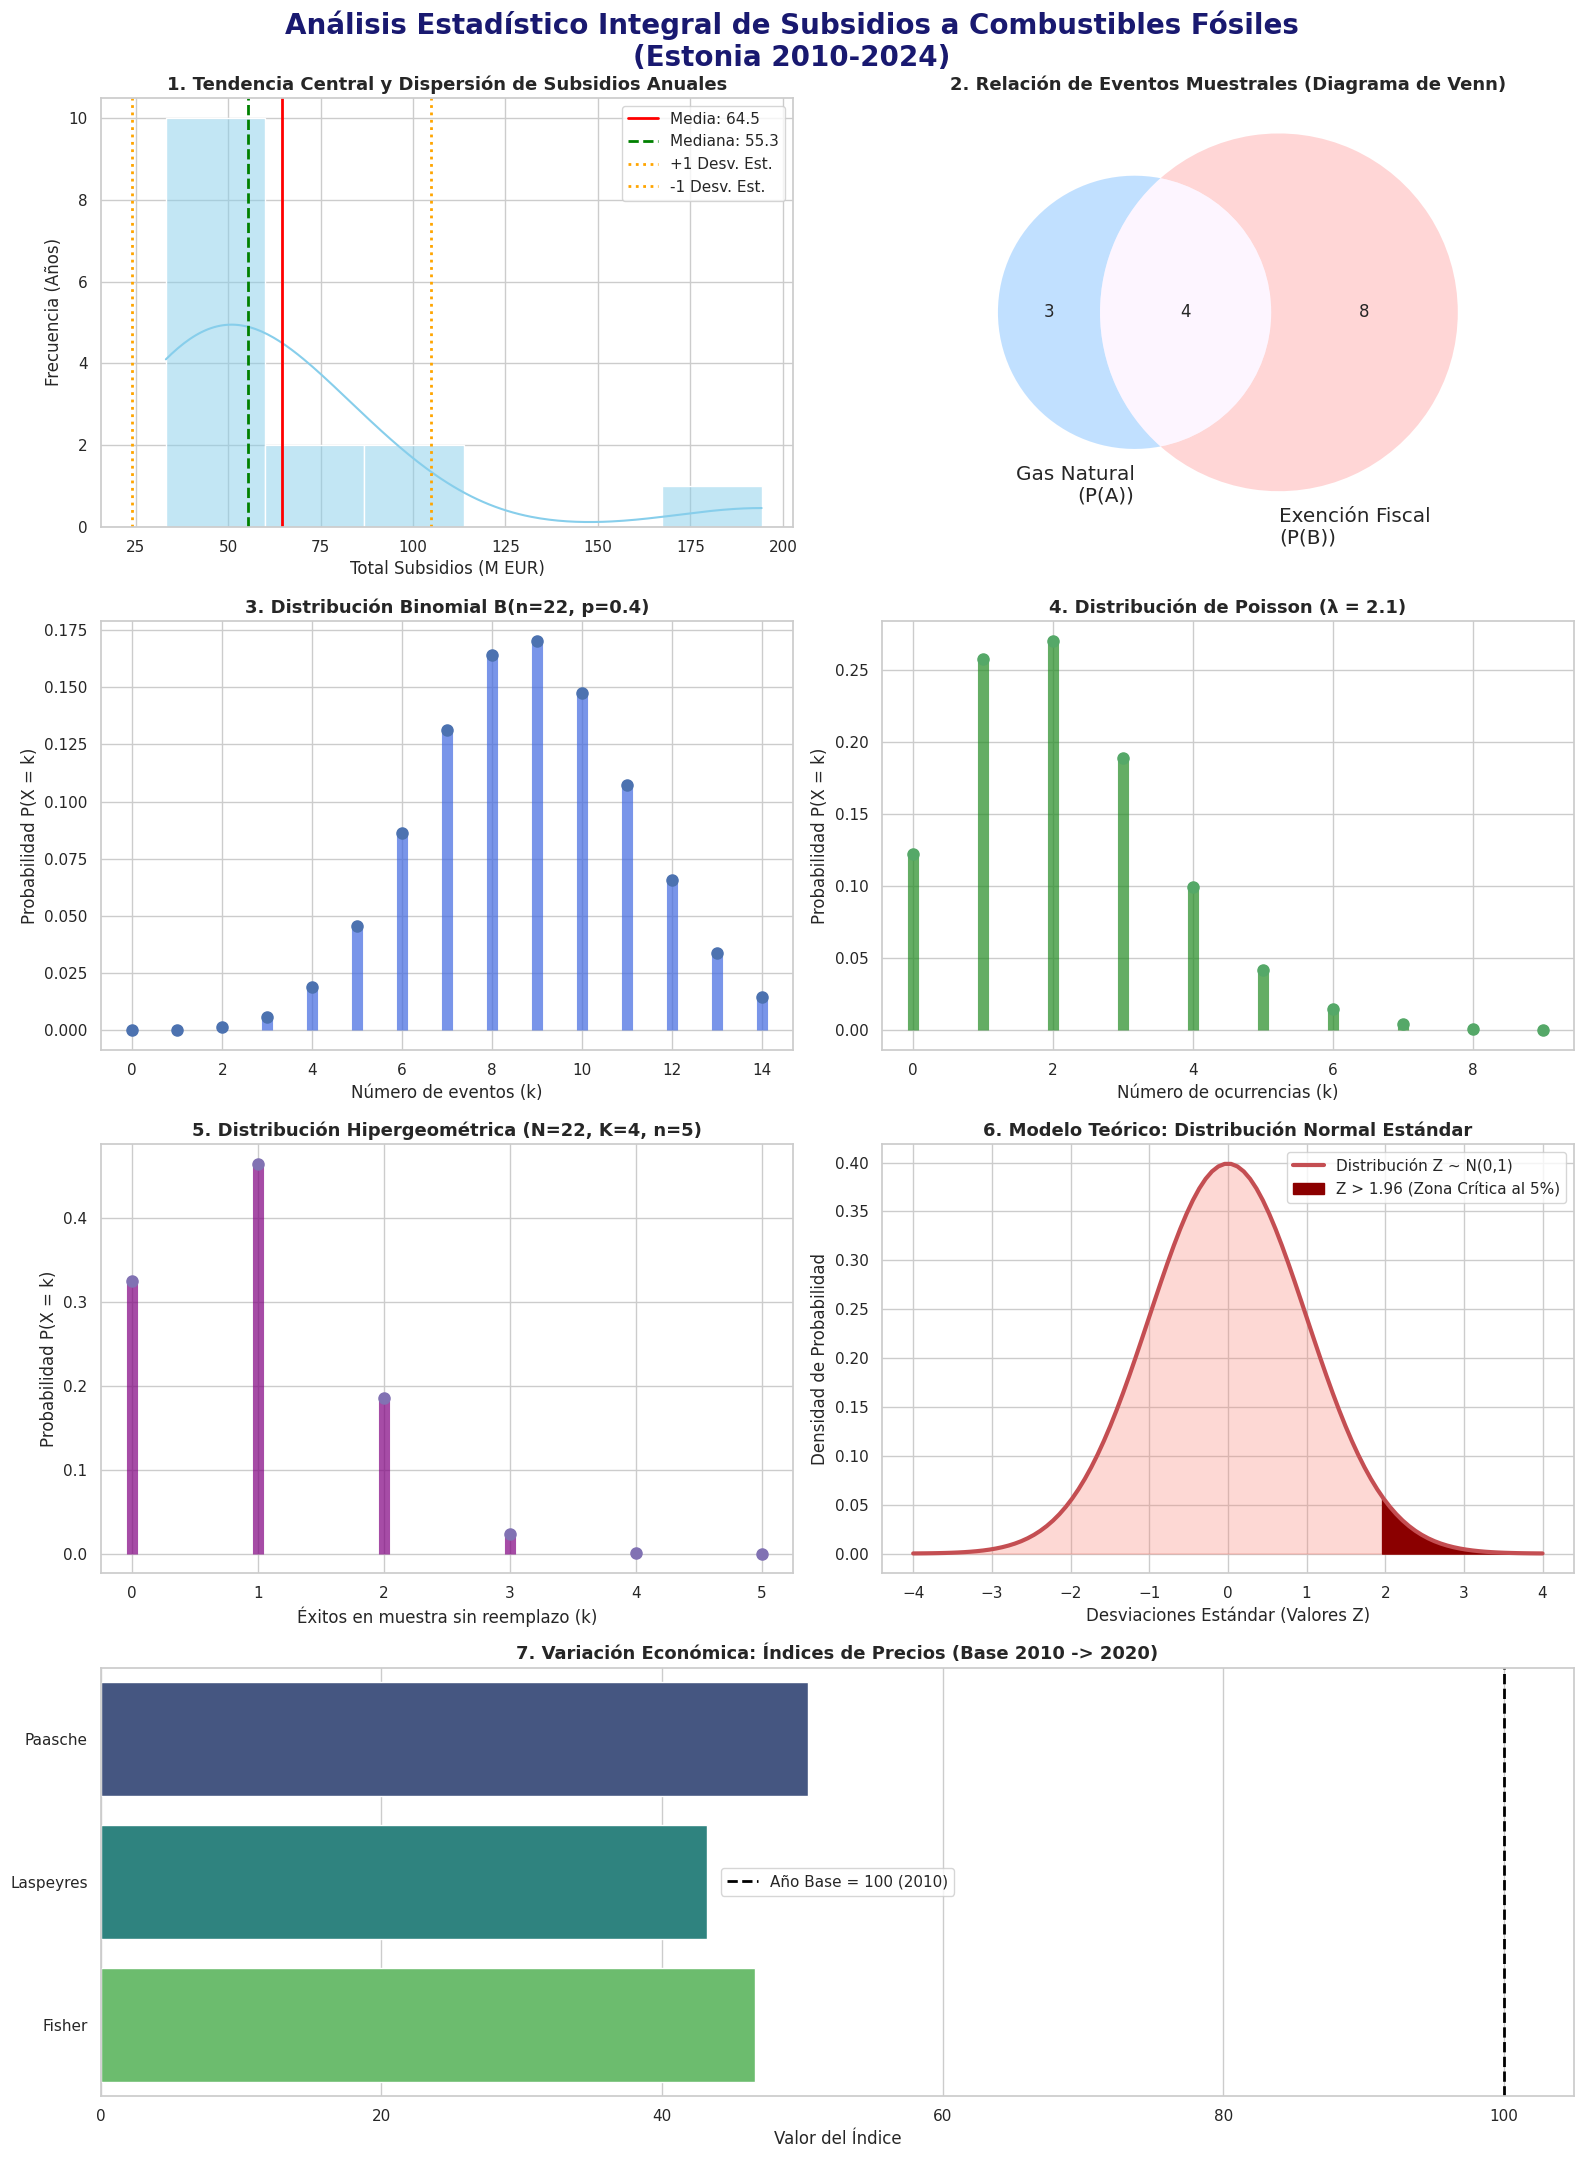

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from matplotlib_venn import venn2

# Configuración visual
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(16, 22))

# --- TÍTULO CORREGIDO PARA QUE SEA PROFESIONAL ---
fig.suptitle('Análisis Estadístico Integral de Subsidios a Combustibles Fósiles\n(Estonia 2010-2024)',
             fontsize=20, fontweight='bold', y=0.98, color='midnightblue')

# ===========================================================================
# 1. Medidas de Tendencia Central y Dispersión
# ===========================================================================
ax1 = plt.subplot(4, 2, 1)
sns.histplot(totales, kde=True, color='skyblue', ax=ax1, bins=6)
ax1.axvline(media, color='red', linestyle='-', linewidth=2, label=f'Media: {media:.1f}')
ax1.axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.1f}')
ax1.axvline(media + std_mue, color='orange', linestyle=':', linewidth=2, label=f'+1 Desv. Est.')
ax1.axvline(media - std_mue, color='orange', linestyle=':', linewidth=2, label=f'-1 Desv. Est.')
ax1.set_title('1. Tendencia Central y Dispersión de Subsidios Anuales', fontsize=13, fontweight='bold')
ax1.set_xlabel('Total Subsidios (M EUR)')
ax1.set_ylabel('Frecuencia (Años)')
ax1.legend()

# ===========================================================================
# 2. Diagrama de Venn (Probabilidad)
# ===========================================================================
ax2 = plt.subplot(4, 2, 2)
solo_gas = n_gas - n_AB
solo_exencion = n_B - n_AB
interseccion = n_AB

venn = venn2(subsets=(solo_gas, solo_exencion, interseccion),
             set_labels=('Gas Natural\n(P(A))', 'Exención Fiscal\n(P(B))'), ax=ax2,
             set_colors=('#66b3ff', '#ff9999'))
ax2.set_title('2. Relación de Eventos Muestrales (Diagrama de Venn)', fontsize=13, fontweight='bold')

# ===========================================================================
# 3. Distribución Binomial (VAD)
# ===========================================================================
ax3 = plt.subplot(4, 2, 3)
x_bin = np.arange(0, 15)
y_bin = stats.binom.pmf(x_bin, n_bin, p_bin)
ax3.vlines(x_bin, 0, y_bin, colors='royalblue', lw=8, alpha=0.7)
ax3.plot(x_bin, y_bin, 'bo', ms=8)
ax3.set_title(f'3. Distribución Binomial B(n={n_bin}, p={p_bin})', fontsize=13, fontweight='bold')
ax3.set_xlabel('Número de eventos (k)')
ax3.set_ylabel('Probabilidad P(X = k)')

# ===========================================================================
# 4. Distribución Poisson (VAD)
# ===========================================================================
ax4 = plt.subplot(4, 2, 4)
x_pois = np.arange(0, 10)
y_pois = stats.poisson.pmf(x_pois, lam)
ax4.vlines(x_pois, 0, y_pois, colors='forestgreen', lw=8, alpha=0.7)
ax4.plot(x_pois, y_pois, 'go', ms=8)
ax4.set_title(f'4. Distribución de Poisson (λ = {lam})', fontsize=13, fontweight='bold')
ax4.set_xlabel('Número de ocurrencias (k)')
ax4.set_ylabel('Probabilidad P(X = k)')

# ===========================================================================
# 5. Distribución Hipergeométrica (VAD)
# ===========================================================================
ax5 = plt.subplot(4, 2, 5)
x_hyp = np.arange(0, n_hip + 1)
y_hyp = stats.hypergeom.pmf(x_hyp, N_hip, K_hip, n_hip)
ax5.vlines(x_hyp, 0, y_hyp, colors='purple', lw=8, alpha=0.7)
ax5.plot(x_hyp, y_hyp, 'mo', ms=8)
ax5.set_title(f'5. Distribución Hipergeométrica (N={N_hip}, K={K_hip}, n={n_hip})', fontsize=13, fontweight='bold')
ax5.set_xlabel('Éxitos en muestra sin reemplazo (k)')
ax5.set_ylabel('Probabilidad P(X = k)')

# ===========================================================================
# 6. Distribución Normal Estándar (VAC)
# ===========================================================================
ax6 = plt.subplot(4, 2, 6)
x_z = np.linspace(-4, 4, 100)
y_z = stats.norm.pdf(x_z, 0, 1)
ax6.plot(x_z, y_z, 'r-', lw=3, label='Distribución Z ~ N(0,1)')
ax6.fill_between(x_z, y_z, alpha=0.3, color='salmon')
x_z_crit = np.linspace(1.96, 4, 50)
y_z_crit = stats.norm.pdf(x_z_crit, 0, 1)
ax6.fill_between(x_z_crit, y_z_crit, color='darkred', label='Z > 1.96 (Zona Crítica al 5%)')

ax6.set_title('6. Modelo Teórico: Distribución Normal Estándar', fontsize=13, fontweight='bold')
ax6.set_xlabel('Desviaciones Estándar (Valores Z)')
ax6.set_ylabel('Densidad de Probabilidad')
ax6.legend()

# ===========================================================================
# 7. Índices de Precios
# ===========================================================================
ax7 = plt.subplot(4, 2, (7, 8))
nombres_indices = ['Paasche', 'Laspeyres', 'Fisher']
valores_indices = [IP, IL, IF]

sns.barplot(x=valores_indices, y=nombres_indices, palette='viridis', ax=ax7)
ax7.axvline(100, color='black', linestyle='--', lw=2, label='Año Base = 100 (2010)')
ax7.set_title('7. Variación Económica: Índices de Precios (Base 2010 -> 2020)', fontsize=13, fontweight='bold')
ax7.set_xlabel('Valor del Índice')
ax7.legend()

plt.tight_layout()
fig.subplots_adjust(top=0.94) # Ajustado para el nuevo título
plt.show()

In [1]:
%%writefile proyecto_nusc.tex
\documentclass[12pt,spanish]{article}
\usepackage[utf8]{inputenc}
\usepackage[T1]{fontenc}
\usepackage{graphicx}
\usepackage{geometry}
\geometry{margin=1in}
\usepackage{babel}
\usepackage{enumitem}

\title{\textbf{Análisis Estadístico Integral de Subsidios a Combustibles Fósiles}\\\large Estonia (2010-2024)}
\author{Nestor Uriel Sánchez Cuevas}
\date{\today}

\begin{document}
\maketitle

\section{Introducción}
Este informe técnico automatizado recopila las métricas clave obtenidas a partir del procesamiento de datos de subsidios a combustibles fósiles en Estonia. En total, se analizaron un histórico de 70 registros instrumentales del periodo establecido.

\section{Métricas de Tendencia Central y Dispersión}
A partir de las funciones analíticas programadas en Python, se han obtenido los siguientes estadísticos descriptivos fundamentales para la muestra de subsidios anuales:
\begin{itemize}
    \item \textbf{Media aritmética:} 64.51 M EUR
    \item \textbf{Mediana:} 55.30 M EUR
    \item \textbf{Desviación Estándar:} 31.22 M EUR
\end{itemize}

\section{Visualización de Resultados Integrales}
El procesamiento gráfico consolida en una única visualización el comportamiento de las frecuencias de los subsidios, las relaciones de eventos muestrales mediante diagramas de Venn (Gas Natural y Exención Fiscal) y los modelos de distribución probabilística teórica (Binomial y Poisson):

\begin{figure}[htbp]
    \centering
    \includegraphics[width=0.9\textwidth]{mosaico_subsidios.png}
    \caption{Mosaico de análisis estadístico integral (Proyecto NUSC).}
\end{figure}

\section{Conclusiones y Modelado}
La distribución empírica de los datos permite contrastar el comportamiento histórico real contra las aproximaciones de probabilidad de eventos discretos. Las herramientas de generación dinámica demuestran la viabilidad de reportes automatizados enlazando entornos de ejecución científica con sistemas de composición tipográfica.\\

Fin del reporte.
\end{document}

Writing proyecto_nusc.tex
